Caricamento dati di vorticità e funzione di corrente...
Tempo richiesto: 15.0 | Tempo usato: 15.0 (Frame: 750)


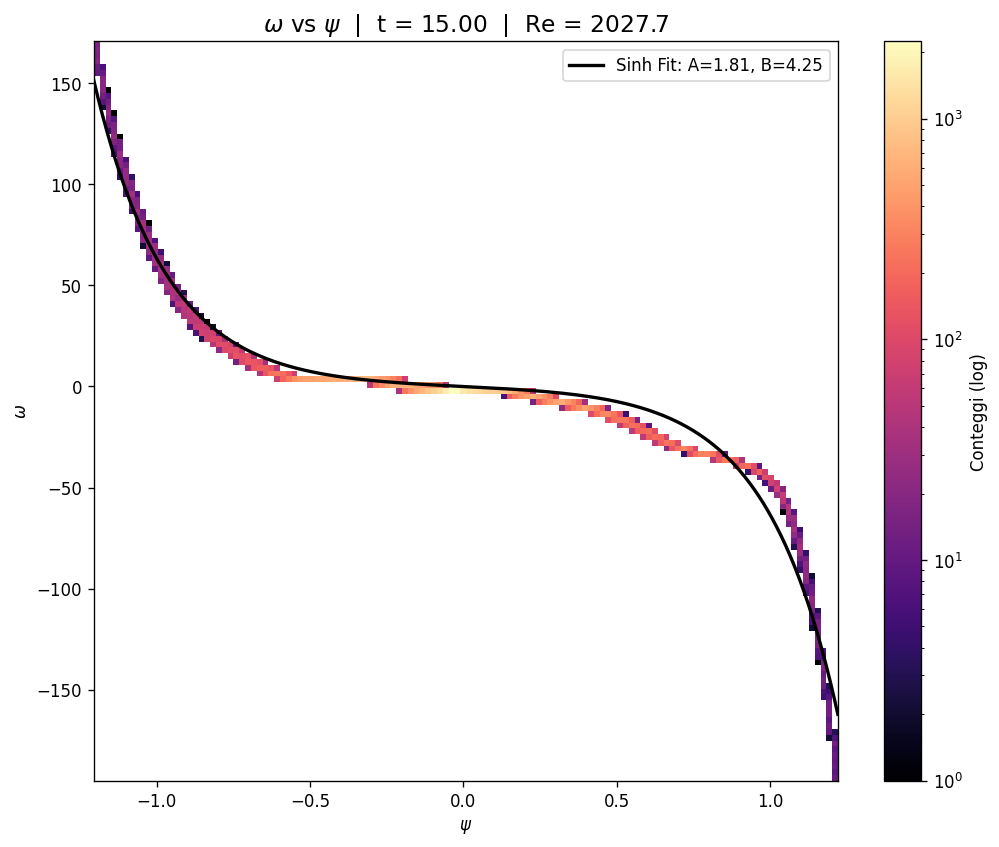

ANALISI FISICA E DI POST-PROCESSING AL TEMPO t = 15.0
  v_rms (da Energia Totale) = 3.06691
  L (Scala Integrale dallo Spettro) = 0.01653
  Numero di Reynolds Re = 2027.71
Parametri ottimizzati del fit teorico (Montgomery):
  A (Ampiezza) = 1.806838
  B (Fattore di forma) = 4.247546


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm

TARGET_TIME = 1.0
POINTS_PER_FRAME = 65536
NU_COSTANTE = 2.5e-5

def load_frames(path):
    times = []
    frames = []
    current_frame = []
    current_time = None

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                if line.startswith("# Time:"):
                    if len(current_frame) == POINTS_PER_FRAME:
                        times.append(current_time)
                        frames.append(np.array(current_frame))
                    current_frame = []
                    current_time = float(line.split(":")[1].strip())
                continue
            
            parts = line.split()
            if len(parts) >= 3:
                try:
                    current_frame.append(float(parts[2]))
                except ValueError:
                    pass

        if len(current_frame) == POINTS_PER_FRAME:
            times.append(current_time)
            frames.append(np.array(current_frame))

    return times, frames


def calcola_reynolds_strada2(target_time, energy_path="energy_total.dat", spectrum_path="energy_spectrum.dat", nu=2.5e-5):
    # 1. Lettura di v_rms dal file dell'energia cinetica totale
    t_energy = []
    E_vals = []
    
    with open(energy_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    t_energy.append(float(parts[0]))
                    E_vals.append(float(parts[1]))
                except ValueError:
                    pass
                    
    t_energy = np.array(t_energy)
    E_vals = np.array(E_vals)
    
    idx_e = np.argmin(np.abs(t_energy - target_time))
    E_target = E_vals[idx_e]
    v_rms = np.sqrt(2.0 * E_target) if E_target > 0 else 0.0

    # 2. Calcolo di L: Prima mappiamo dove si trovano i vari blocchi temporali nello spettro
    spec_times = []
    with open(spectrum_path, "r") as f:
        for line in f:
            if line.startswith("# Time:"):
                spec_times.append(float(line.split(":")[1].strip()))
    
    if not spec_times:
        print("Errore: Nessun marcatore temporale trovato in energy_spectrum.dat")
        return 0.0, v_rms, 1.0
        
    spec_times = np.array(spec_times)
    # Troviamo il tempo più vicino tra quelli disponibili nel file dello spettro
    best_spec_time = spec_times[np.argmin(np.abs(spec_times - target_time))]

    # Ora rileggiamo il file estraendo SOLO le righe di quel blocco temporale
    k_vals = []
    Ek_vals = []
    leggi_dati = False
    
    with open(spectrum_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("# Time:"):
                t = float(line.split(":")[1].strip())
                if leggi_dati: # Se stavamo già leggendo il blocco giusto e incontriamo il prossimo tempo, ci fermiamo
                    break
                if abs(t - best_spec_time) < 1e-6:
                    leggi_dati = True
                continue
            
            if leggi_dati:
                parts = line.split()
                if len(parts) >= 2:
                    try:
                        k = float(parts[0])
                        Ek = float(parts[1])
                        if k > 0: 
                            k_vals.append(k)
                            Ek_vals.append(Ek)
                    except ValueError:
                        pass

    if len(k_vals) > 0:
        k_vals = np.array(k_vals)
        Ek_vals = np.array(Ek_vals)
        numeratore = np.sum(Ek_vals / k_vals)
        denominatore = np.sum(Ek_vals)
        L = numeratore / denominatore if denominatore > 0 else 1.0
    else:
        print(f"Avviso: Impossibile estrarre i dati dello spettro per t = {best_spec_time}. Uso L = 1.0")
        L = 1.0
        
    # 3. Calcolo finale di Reynolds
    Re = (v_rms * L) / nu
    
    return Re, v_rms, L


# --- FLUSSO PRINCIPALE ---

print("Caricamento dati di vorticità e funzione di corrente...")
w_times, w_evo = load_frames("vorticity_evolution.dat")
psi_times, psi_evo = load_frames("psi_evolution.dat")

# Trova il frame più vicino al TARGET_TIME
diffs = [abs(t - TARGET_TIME) for t in w_times]
frame_idx = np.argmin(diffs)
selected_time = w_times[frame_idx]

psi_f = psi_evo[frame_idx]
omega_f = w_evo[frame_idx]

print(f"Tempo richiesto: {TARGET_TIME} | Tempo usato: {selected_time} (Frame: {frame_idx})")

# --- CALCOLO REYNOLDS (STRADA 2) ---
# Cambia i nomi dei file se si chiamano diversamente (es. energy_evolution.dat)
Re_val, v_rms, L_scala = calcola_reynolds_strada2(
    selected_time, 
    energy_path="energy_total.dat", 
    spectrum_path="energy_spectrum.dat", 
    nu=NU_COSTANTE
)

# --- FIT DI MONTGOMERY ---
def modello_sinh(x, A, B):
    return -A * np.sinh(B * x)

mask_small = np.abs(psi_f) < (np.max(np.abs(psi_f)) * 0.1)
pendenza, _ = np.polyfit(psi_f[mask_small], omega_f[mask_small], 1)
guess_B = 0.1
guess_A = -pendenza / guess_B

try:
    popt_sinh, _ = curve_fit(modello_sinh, psi_f, omega_f, p0=[guess_A, guess_B], maxfev=20000)
    fit_success = True
except Exception as e:
    print(f"Attenzione, il fit ha dato errore: {e}")
    fit_success = False

# --- GRAFICO VORTICITÀ vs FUNZIONE DI CORRENTE ---
plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 8), dpi=120)

bins = 128
hist, xedges, yedges = np.histogram2d(psi_f, omega_f, bins=bins)

im = ax.imshow(
    np.ma.masked_less_equal(hist.T, 0.0),
    origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect="auto",
    cmap="magma",
    norm=LogNorm()
)

fig.colorbar(im, ax=ax, label="Conteggi (log)")

if fit_success:
    xp = np.linspace(psi_f.min(), psi_f.max(), 500)
    ax.plot(
        xp,
        modello_sinh(xp, *popt_sinh),
        "k",
        linewidth=2.0,
        label=f"Sinh Fit: A={popt_sinh[0]:.2f}, B={popt_sinh[1]:.2f}"
    )

ax.set_xlabel(r"$\psi$")
ax.set_ylabel(r"$\omega$")

# Titolo aggiornato con Tempo e Reynolds
ax.set_title(f"$\\omega$ vs $\\psi$  |  t = {selected_time:.2f}  |  Re = {Re_val:.1f}", fontsize=14)
ax.legend()
plt.show()

# --- PRINT RIASSUNTIVO SOTTO IL GRAFICO ---
print("="*50)
print(f"ANALISI FISICA E DI POST-PROCESSING AL TEMPO t = {selected_time}")
print(f"  v_rms (da Energia Totale) = {v_rms:.5f}")
print(f"  L (Scala Integrale dallo Spettro) = {L_scala:.5f}")
print(f"  Numero di Reynolds Re = {Re_val:.2f}")
print("="*50)
if fit_success:
    print("Parametri ottimizzati del fit teorico (Montgomery):")
    print(f"  A (Ampiezza) = {popt_sinh[0]:.6f}")
    print(f"  B (Fattore di forma) = {popt_sinh[1]:.6f}")
else:
    print("Il fit non è andato a buon fine per questo frame.")
print("="*50)
